# Lab 2 — Diffusion Models: UNet DDPM from Scratch
**COM SCI-X 455 · Week 2 · Megan Armani, PhD**

> Push to `genai-course/week2/`

---

## Setup

In [1]:
!pip install diffusers accelerate torch torchvision matplotlib --quiet

In [2]:
import torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", DEVICE)

Device: cuda


## Note on Homework Extension
The **lab** trains on MNIST. Your **homework** extends to FashionMNIST:
```python
# One-line swap:
train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
```
The UNet and training loop are identical. FashionMNIST is harder — observe how many epochs your model needs vs MNIST.

## Part 1 — Forward Process (Noise Schedule)
**Goal:** Implement the linear and cosine variance schedules and visualise what they do to an image.

In [3]:
def linear_schedule(T=1000, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, T)

def cosine_schedule(T=1000, s=0.008):
    steps = torch.arange(T+1, dtype=torch.float32)
    f = torch.cos(((steps/T + s) / (1+s)) * torch.pi/2) ** 2
    alphas_bar = f / f[0]
    betas = 1 - (alphas_bar[1:] / alphas_bar[:-1])
    return torch.clamp(betas, 0, 0.999)

In [4]:
# TODO: Implement `q_sample(x0, t, betas)` — the closed-form forward process.
def q_sample(x_0, t, betas, eps=None):
  betas = betas.to(x_0.device) #beta_t is the noise added per step
  alphas = 1.0 - betas #signal kept per step

  alpha_bars = torch.cumprod(alphas, dim=0)

  t = torch.as_tensor(t, device=x_0.device, dtype=torch.long)

  #Change shape so it broadcasts correctly
  alpha_bar_t = alpha_bars[t].view(-1, 1, 1, 1)
  if eps is None:
    eps = torch.randn_like(x_0)

  #Apply diffusion equation
  x_t = torch.sqrt(alpha_bar_t) * x_0 + torch.sqrt(1 - alpha_bar_t) * eps
  return x_t, eps


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 518kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.5MB/s]


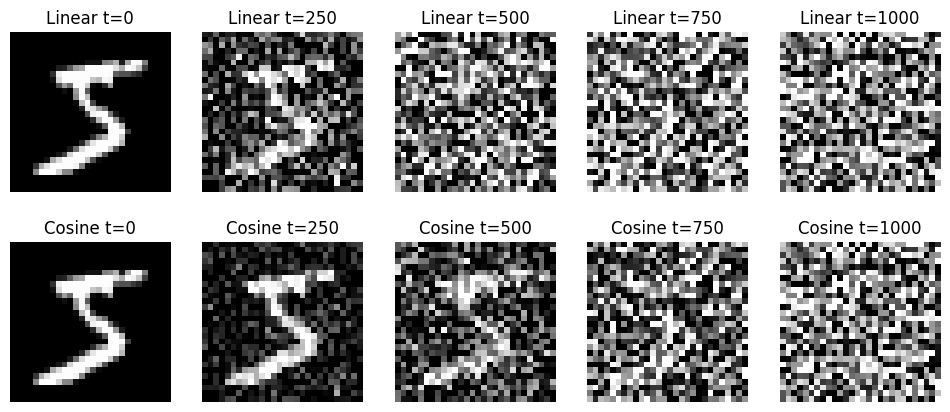

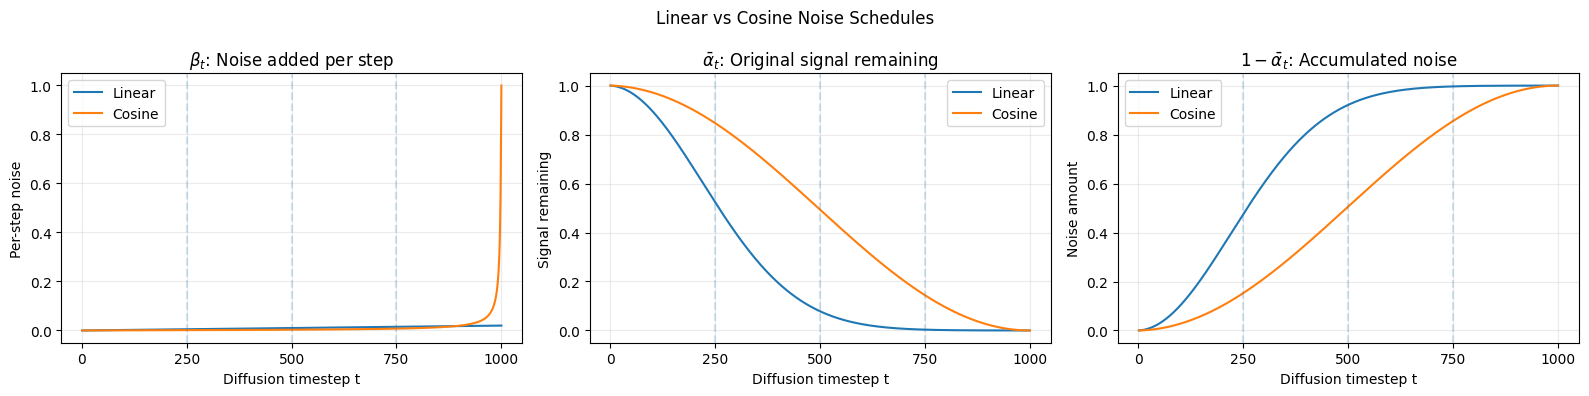

In [5]:
from prompt_toolkit.styles import style_from_pygments_dict
# TODO: Visualise the noising process: take one MNIST image, show it at t=0, 250, 500, 750, 1000
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Lambda(lambda x: x*2.0 - 1.0)])
train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

#Grab an example
x0, label = train_data[0]
#change dims from (1,28,28) to (1,1,28,28)
x0 = x0.unsqueeze(0).to(DEVICE)

T = 1000
schedules = {"Linear": linear_schedule(T).to(DEVICE), "Cosine": cosine_schedule(T).to(DEVICE)}

display_steps = [0,250,500,750,1000]

#Use identical random noise across both schedules for comparison
noise_bank = {step: torch.randn_like(x0) for step in display_steps if step>0}

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for row, (schedule_name, betas) in enumerate(schedules.items()):
  for col, step in enumerate(display_steps):
    if step == 0:
      #show the original image
      x_t = x0
    else:
      #display steps 250 and 1000
      t_index = min(step-1,T-1)
      t = torch.tensor([t_index], device=DEVICE)
      x_t, _ = q_sample(x0, t, betas, eps=noise_bank[step])

    #Get image and change [-1,1]->[0,1] for plotting
    image = (x_t[0,0].clamp(-1,1)+1.0)/2.0

    #plot
    axes[row,col].imshow(image.detach().cpu().numpy(), cmap="gray")
    axes[row,col].axis("off")
    if row==0:
      axes[row,col].set_title(f"t={step}")
    axes[row,0].set_ylabel(schedule_name)
    axes[row,col].set_title(f"{schedule_name} t={step}")


# Visualize what each schedule is actually doing
T = 1000

schedule_betas = {
    "Linear": linear_schedule(T).cpu(),
    "Cosine": cosine_schedule(T).cpu()
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for name, betas in schedule_betas.items():

    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    timesteps = torch.arange(1, T + 1)

    # Noise added at each individual step
    axes[0].plot(timesteps, betas, label=name)

    # Original signal remaining overall
    axes[1].plot(timesteps, alpha_bars, label=name)

    # Total corruption/noise accumulated
    axes[2].plot(timesteps, 1.0 - alpha_bars, label=name)


for ax in axes:

    for t in [250, 500, 750]:
        ax.axvline(t, linestyle="--", alpha=0.2)

    ax.set_xlabel("Diffusion timestep t")
    ax.set_xticks([0, 250, 500, 750, 1000])
    ax.grid(alpha=0.25)
    ax.legend()


axes[0].set_title(r"$\beta_t$: Noise added per step")
axes[0].set_ylabel("Per-step noise")

axes[1].set_title(r"$\bar{\alpha}_t$: Original signal remaining")
axes[1].set_ylabel("Signal remaining")

axes[2].set_title(r"$1-\bar{\alpha}_t$: Accumulated noise")
axes[2].set_ylabel("Noise amount")

plt.suptitle("Linear vs Cosine Noise Schedules")
plt.tight_layout()
plt.show()

The cosine schedule seems to be milder with corruption of the image than the linear schedule. The linear schedule shows faster corruption at earlier timesteps while cosine starts mild before aggressive corrpution at later timesteps. The code here uses the same image and noise but differing schedules to prevent bias from random noise sampling.

For me, it is already at epoch 250 that the difference is noticeable. Edge sharpeness, noise, and digit completeness are are clearly stronger in the cosine schedule compare to the linear. The supplementary noise scheudle graphs also shwo the rate of signal remaining and acculamated noise, showing and proving the linear schedule both loses signal and gains noise at higher rates than cosine.

## Part 2 — U-Net Noise Predictor

In [6]:
class SinusoidalTimeEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-torch.arange(half, device=t.device) * (torch.log(torch.tensor(10000.0)) / (half-1)))
        args  = t[:, None].float() * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class ResBlock(nn.Module):
    def __init__(self, ch, time_dim):
        super().__init__()
        self.conv1  = nn.Conv2d(ch, ch, 3, padding=1)
        self.conv2  = nn.Conv2d(ch, ch, 3, padding=1)
        self.time_mlp = nn.Linear(time_dim, ch)
        self.norm1  = nn.GroupNorm(8, ch)
        self.norm2  = nn.GroupNorm(8, ch)
    def forward(self, x, t_emb):
        h = self.norm1(x)
        h = torch.relu(self.conv1(h))
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.norm2(h)
        return x + self.conv2(torch.relu(h))

In [7]:
class UNet(nn.Module):
    def __init__(self, time_dim=128):
        super().__init__()

        # ---------------------------------------------------------
        # TLDR: Convert integer timestep t into a meaningful vector.
        # ---------------------------------------------------------
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmb(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.ReLU()
        )

        # ---------------------------------------------------------
        # Input: (B, 1, 28, 28)
        # ---------------------------------------------------------
        self.in_conv = nn.Conv2d(
            1, 32, kernel_size=3, padding=1
        )

        # ---------------------------------------------------------
        # Encoder
        #
        # 28x28 @ 32
        #   -> 14x14 @ 64
        #   -> 7x7   @ 128
        #   -> 4x4   @ 128
        # ---------------------------------------------------------
        self.enc1 = ResBlock(32, time_dim)
        self.down1 = nn.Conv2d(
            32, 64, kernel_size=4, stride=2, padding=1
        )

        self.enc2 = ResBlock(64, time_dim)
        self.down2 = nn.Conv2d(
            64, 128, kernel_size=4, stride=2, padding=1
        )

        self.enc3 = ResBlock(128, time_dim)

        # 7 -> 4 requires a slightly different kernel
        self.down3 = nn.Conv2d(
            128, 128, kernel_size=3, stride=2, padding=1
        )

        # ---------------------------------------------------------
        # Bottleneck
        # ---------------------------------------------------------
        self.mid = ResBlock(128, time_dim)

        # ---------------------------------------------------------
        # Decoder
        #
        # 4x4 -> 7x7 -> 14x14 -> 28x28
        #
        # Each level:
        # upsample -> concatenate skip -> reduce channels -> ResBlock
        # ---------------------------------------------------------

        # 4 -> 7
        self.up3 = nn.ConvTranspose2d(
            128, 128,
            kernel_size=3,
            stride=2,
            padding=1
        )

        # 128 decoder + 128 skip = 256 -> 128
        self.merge3 = nn.Conv2d(256, 128, kernel_size=1)
        self.dec3 = ResBlock(128, time_dim)

        # 7 -> 14
        self.up2 = nn.ConvTranspose2d(
            128, 64,
            kernel_size=4,
            stride=2,
            padding=1
        )

        # 64 decoder + 64 skip = 128 -> 64
        self.merge2 = nn.Conv2d(128, 64, kernel_size=1)
        self.dec2 = ResBlock(64, time_dim)

        # 14 -> 28
        self.up1 = nn.ConvTranspose2d(
            64, 32,
            kernel_size=4,
            stride=2,
            padding=1
        )

        # 32 decoder + 32 skip = 64 -> 32
        self.merge1 = nn.Conv2d(64, 32, kernel_size=1)
        self.dec1 = ResBlock(32, time_dim)

        # Predict one noise value per input pixel
        self.out_conv = nn.Conv2d(
            32, 1, kernel_size=1
        )

    def forward(self, x, t):

        # TLDR: every image gets told "how noisy am I?"
        t_emb = self.time_embed(t)

        # ---------------- Encoder ----------------
        s1 = self.enc1(
            self.in_conv(x),
            t_emb
        )                                  # (B, 32, 28, 28)

        s2 = self.enc2(
            self.down1(s1),
            t_emb
        )                                  # (B, 64, 14, 14)

        s3 = self.enc3(
            self.down2(s2),
            t_emb
        )                                  # (B, 128, 7, 7)

        # ---------------- Bottleneck ----------------
        h = self.mid(
            self.down3(s3),
            t_emb
        )                                  # (B, 128, 4, 4)

        # ---------------- Decoder level 3 ----------------
        h = self.up3(h)                    # (B, 128, 7, 7)
        h = torch.cat([h, s3], dim=1)      # (B, 256, 7, 7)
        h = self.merge3(h)                 # (B, 128, 7, 7)
        h = self.dec3(h, t_emb)

        # ---------------- Decoder level 2 ----------------
        h = self.up2(h)                    # (B, 64, 14, 14)
        h = torch.cat([h, s2], dim=1)      # (B, 128, 14, 14)
        h = self.merge2(h)                 # (B, 64, 14, 14)
        h = self.dec2(h, t_emb)

        # ---------------- Decoder level 1 ----------------
        h = self.up1(h)                    # (B, 32, 28, 28)
        h = torch.cat([h, s1], dim=1)      # (B, 64, 28, 28)
        h = self.merge1(h)                 # (B, 32, 28, 28)
        h = self.dec1(h, t_emb)

        # No sigmoid/tanh:
        # Gaussian noise can contain any real value.
        return self.out_conv(h)

## Part 3 — Training Loop

Cosine | Epoch 01/20 | Loss = 0.0871
Cosine | Epoch 02/20 | Loss = 0.0514
Cosine | Epoch 03/20 | Loss = 0.0473
Cosine | Epoch 04/20 | Loss = 0.0454
Cosine | Epoch 05/20 | Loss = 0.0442
Cosine | Epoch 06/20 | Loss = 0.0436
Cosine | Epoch 07/20 | Loss = 0.0429
Cosine | Epoch 08/20 | Loss = 0.0425
Cosine | Epoch 09/20 | Loss = 0.0425
Cosine | Epoch 10/20 | Loss = 0.0414
Cosine | Epoch 11/20 | Loss = 0.0418
Cosine | Epoch 12/20 | Loss = 0.0411
Cosine | Epoch 13/20 | Loss = 0.0409
Cosine | Epoch 14/20 | Loss = 0.0408
Cosine | Epoch 15/20 | Loss = 0.0407
Cosine | Epoch 16/20 | Loss = 0.0403
Cosine | Epoch 17/20 | Loss = 0.0405
Cosine | Epoch 18/20 | Loss = 0.0400
Cosine | Epoch 19/20 | Loss = 0.0403
Cosine | Epoch 20/20 | Loss = 0.0402
Linear | Epoch 01/20 | Loss = 0.0567
Linear | Epoch 02/20 | Loss = 0.0313
Linear | Epoch 03/20 | Loss = 0.0288
Linear | Epoch 04/20 | Loss = 0.0272
Linear | Epoch 05/20 | Loss = 0.0262
Linear | Epoch 06/20 | Loss = 0.0259
Linear | Epoch 07/20 | Loss = 0.0255
L

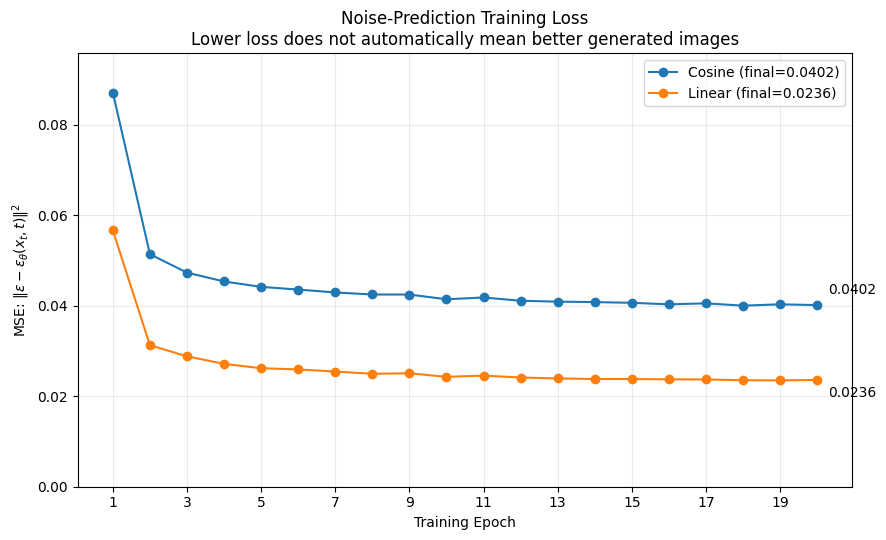

In [8]:
import torch.nn.functional as F

# ---------------------------------------------------------
# Hyperparameters
# ---------------------------------------------------------
T = 1000
BATCH_SIZE = 128
EPOCHS = 20
LR = 1e-3

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)


def train_ddpm(schedule_name):
    """
    Train a fresh DDPM model using either:
    - "linear"
    - "cosine"

    Returns:
        model
        betas
        loss_history
    """

    # -----------------------------------------------------
    # TLDR: reset seed so both experiments start similarly
    # -----------------------------------------------------
    torch.manual_seed(42)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(42)

    # -----------------------------------------------------
    # Pick noise schedule
    # -----------------------------------------------------
    if schedule_name == "cosine":
        betas = cosine_schedule(T).to(DEVICE)

    elif schedule_name == "linear":
        betas = linear_schedule(T).to(DEVICE)

    else:
        raise ValueError("schedule_name must be 'linear' or 'cosine'")

    # -----------------------------------------------------
    # IMPORTANT:
    # Fresh model for each schedule.
    # -----------------------------------------------------
    model = UNet().to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LR
    )

    loss_history = []

    # -----------------------------------------------------
    # Training loop
    # -----------------------------------------------------
    for epoch in range(EPOCHS):

        model.train()
        running_loss = 0.0

        for x0, _ in train_loader:

            x0 = x0.to(DEVICE)

            # Random diffusion timestep for every image
            t = torch.randint(
                0,
                T,
                (x0.shape[0],),
                device=DEVICE
            )

            # Add noise according to this schedule
            x_t, eps = q_sample(
                x0,
                t,
                betas
            )

            # Predict the noise
            eps_pred = model(
                x_t,
                t
            )

            # Compare predicted vs true noise
            loss = F.mse_loss(
                eps_pred,
                eps
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)

        loss_history.append(avg_loss)

        print(
            f"{schedule_name.capitalize():6s} "
            f"| Epoch {epoch + 1:02d}/{EPOCHS} "
            f"| Loss = {avg_loss:.4f}"
        )

    return model, betas, loss_history


# =========================================================
# Train BOTH schedules
# =========================================================

cosine_model, cosine_betas, cosine_loss = train_ddpm(
    "cosine"
)

linear_model, linear_betas, linear_loss = train_ddpm(
    "linear"
)


# =========================================================
# Plot both training curves
# =========================================================

epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(9, 5.5))

plt.plot(
    epochs,
    cosine_loss,
    marker="o",
    label=f"Cosine (final={cosine_loss[-1]:.4f})"
)

plt.plot(
    epochs,
    linear_loss,
    marker="o",
    label=f"Linear (final={linear_loss[-1]:.4f})"
)

plt.xlabel("Training Epoch")

plt.ylabel(
    r"MSE: $\|\epsilon-\epsilon_\theta(x_t,t)\|^2$"
)

plt.title(
    "Noise-Prediction Training Loss\n"
    "Lower loss does not automatically mean better generated images"
)

plt.xticks(
    range(1, EPOCHS + 1, 2)
)

plt.ylim(
    0,
    max(cosine_loss + linear_loss) * 1.1
)

plt.grid(alpha=0.25)
plt.legend()

# Show final numerical loss directly on plot
plt.annotate(
    f"{cosine_loss[-1]:.4f}",
    (EPOCHS, cosine_loss[-1]),
    xytext=(8, 8),
    textcoords="offset points"
)

plt.annotate(
    f"{linear_loss[-1]:.4f}",
    (EPOCHS, linear_loss[-1]),
    xytext=(8, -12),
    textcoords="offset points"
)

plt.tight_layout()
plt.show()

## Part 4 — DDIM vs DDPM Sampling

In [9]:
# DDPM sampling (1000 steps — slow)
@torch.no_grad()
def ddpm_sample(model, betas, T=1000, shape=(1,1,28,28)):
    alphas     = 1 - betas
    alpha_bars = torch.cumprod(alphas, dim=0).to(DEVICE)
    x = torch.randn(shape).to(DEVICE)
    for t in reversed(range(T)):
        t_tensor = torch.tensor([t]).to(DEVICE)
        eps_pred = model(x, t_tensor)
        alpha_bar_t = alpha_bars[t]
        alpha_bar_prev = alpha_bars[t-1] if t > 0 else torch.tensor(1.0)
        # posterior mean
        coef1 = betas[t] / (1 - alpha_bar_t).sqrt()
        x = (1/alphas[t].sqrt()) * (x - coef1 * eps_pred)
        if t > 0:
            noise = torch.randn_like(x)
            x = x + betas[t].sqrt() * noise
    return x

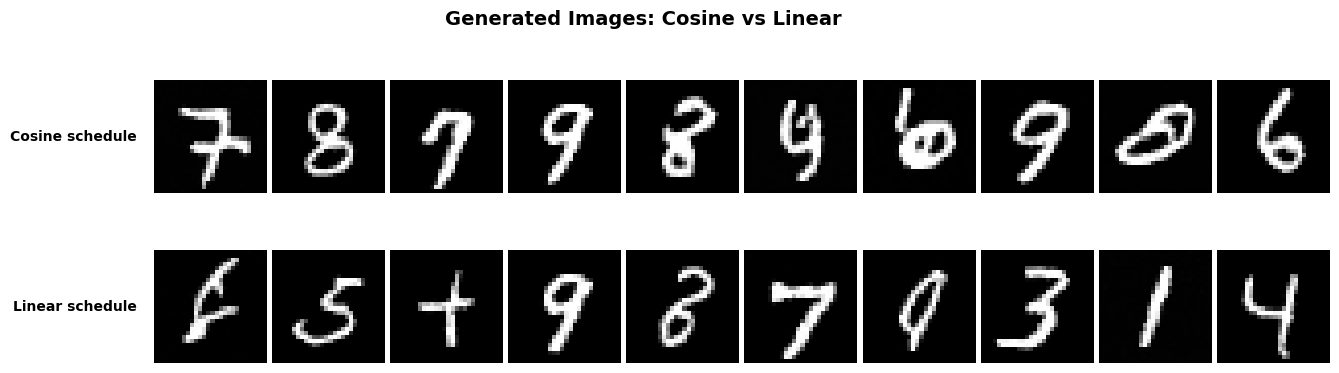

Sampling using the cosine model
DDPM: 14.45s
DDIM: 0.75s
Speedup: 19.34x


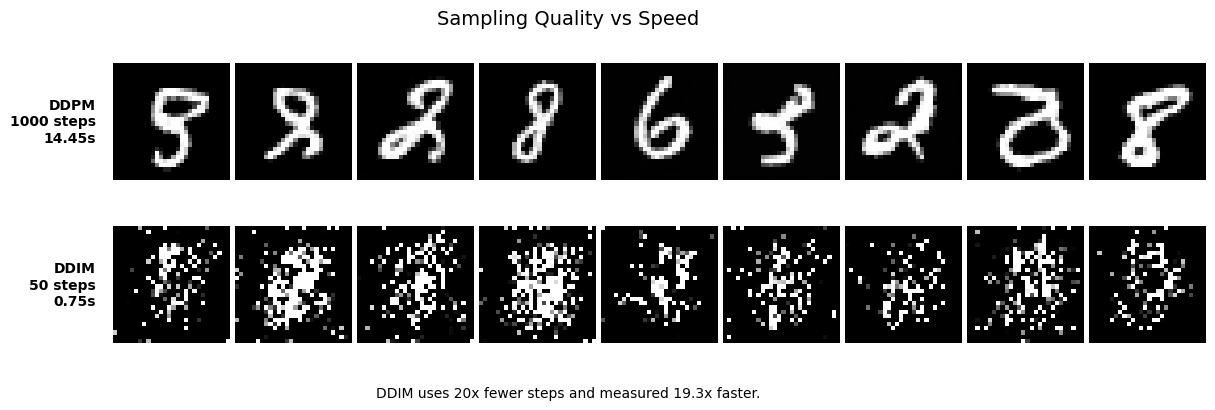

In [11]:
# TODO: Implement `ddim_sample(model, betas, steps=50)` — deterministic, skip timesteps.
import time
@torch.no_grad()
def ddim_sample(model, betas, steps=50, shape=(1,1,28,28), x_t=None):
  model.eval()
  betas= betas.to(DEVICE)
  alphas = 1.0 - betas
  alpha_bars = torch.cumprod(alphas, dim=0).to(DEVICE)
  T = len(betas)

  timesteps = torch.linspace(T-1, 0, steps, device=DEVICE).long()

  #Start with pure Gaussian noise unless we have x_T
  if x_t is None:
    x = torch.randn(shape).to(DEVICE)
  else:
    x = x_t.clone().to(DEVICE)

  for i,t in enumerate(timesteps):
    t_int = int(t.item())

    #Every image in this batch is currently at the same timestep
    t_batch = torch.full((x.shape[0],), t_int, device=DEVICE, dtype=torch.long)

    #Predict the noise currently inside x_t
    eps_pred=model(x,t_batch)

    alpha_bar_t = alpha_bars[t_int]

    #Estimate the clean image x0
    x0_pred = (x-torch.sqrt(1.0-alpha_bar_t)*eps_pred)/torch.sqrt(alpha_bar_t)
    #alpha-bar for the timestep we are jumping to
    if i == len(timesteps)-1:
      #after t=0, clean image has alpha_bar=1
      alpha_bar_prev = torch.tensor(1.0,device=DEVICE)
    else:
      prev_t = int(timesteps[i+1].item())
      alpha_bar_prev = alpha_bars[prev_t]

    #Now the DDIM update (no new random noise)
    x = (torch.sqrt(alpha_bar_prev)*x0_pred + torch.sqrt(1.0-alpha_bar_prev)*eps_pred)

  return x

# =========================================================
# Visual comparison: Cosine vs Linear
# =========================================================

N_COMPARE = 10
comparison_shape = (N_COMPARE, 1, 28, 28)

cosine_model.eval()
linear_model.eval()

torch.manual_seed(42)
cosine_samples = ddpm_sample(
    cosine_model,
    cosine_betas,
    T=len(cosine_betas),
    shape=comparison_shape,
)

# Reset the seed to match the random draws across schedules.
torch.manual_seed(42)
linear_samples = ddpm_sample(
    linear_model,
    linear_betas,
    T=len(linear_betas),
    shape=comparison_shape,
)

# Both cosine_samples and linear_samples now exist.
fig, axes = plt.subplots(
    2,
    N_COMPARE,
    figsize=(14, 4),
    squeeze=False,
)

comparison = [
    ("Cosine schedule", cosine_samples),
    ("Linear schedule", linear_samples),
]

for row, (name, images) in enumerate(comparison):
    for col in range(N_COMPARE):
        image = (images[col, 0].clamp(-1, 1) + 1.0) / 2.0

        axes[row, col].imshow(
            image.detach().cpu(),
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[row, col].axis("off")

    # This is outside the inner loop: one label per row.
    axes[row, 0].text(
        -0.15,
        0.5,
        name,
        transform=axes[row, 0].transAxes,
        ha="right",
        va="center",
        fontsize=10,
        fontweight="bold",
        clip_on=False,
    )

fig.suptitle(
    "Generated Images: Cosine vs Linear",
    fontsize=14,
    fontweight="bold",
)

fig.subplots_adjust(
    left=0.15,
    right=0.99,
    bottom=0.06,
    top=0.84,
    wspace=0.05,
    hspace=0.20,
)

plt.show()

#Timing Comparison
N_SAMPLES, DDIM_STEPS = 100,50
sample_shape = (N_SAMPLES, 1, 28, 28)

def sync_device():
  #GPU operations are asynchronous
  if DEVICE == "cuda":
    torch.cuda.synchronize()

# Choose which trained schedule to evaluate
SAMPLING_SCHEDULE = "cosine"

if SAMPLING_SCHEDULE == "cosine":

    model = cosine_model
    betas = cosine_betas

else:

    model = linear_model
    betas = linear_betas


print(
    f"Sampling using the {SAMPLING_SCHEDULE} model"
)

model.eval()

#DDPM
sync_device()
start = time.perf_counter()
ddpm_images = ddpm_sample(model, betas, T=1000, shape=sample_shape)
sync_device()
ddpm_time = time.perf_counter() - start

#DDIM
sync_device()
start = time.perf_counter()
ddim_images = ddim_sample(model, betas, steps=DDIM_STEPS, shape=sample_shape)
sync_device()
ddim_time = time.perf_counter() - start

print(f"DDPM: {ddpm_time:.2f}s")
print(f"DDIM: {ddim_time:.2f}s")
print(f"Speedup: {ddpm_time/ddim_time:.2f}x")

#Visual Comparison

N_SHOW = 9

fig, axes = plt.subplots(
    2,
    N_SHOW,
    figsize=(13, 4)
)

comparison = [
    (
        f"DDPM\n1000 steps\n{ddpm_time:.2f}s",
        ddpm_images
    ),
    (
        f"DDIM\n{DDIM_STEPS} steps\n{ddim_time:.2f}s",
        ddim_images
    )
]


for row, (name, images) in enumerate(comparison):
    for col in range(N_SHOW):
        image = (images[col, 0].clamp(-1, 1) + 1.0) / 2.0

        axes[row, col].imshow(
            image.detach().cpu(),
            cmap="gray",
            vmin=0,
            vmax=1,
        )
        axes[row, col].axis("off")

    # Four spaces here, not eight:
    # inside the row loop, but outside the column loop.
    axes[row, 0].text(
        -0.15,
        0.5,
        name,
        transform=axes[row, 0].transAxes,
        ha="right",
        va="center",
        fontsize=10,
        fontweight="bold",
        clip_on=False,
    )


plt.suptitle(
    "Sampling Quality vs Speed",
    fontsize=14
)

plt.figtext(
    0.5,
    0.01,
    f"DDIM uses {1000 / DDIM_STEPS:.0f}x fewer steps "
    f"and measured {ddpm_time / ddim_time:.1f}x faster.",
    ha="center"
)

fig.subplots_adjust(
    left=0.15,
    right=0.99,
    bottom=0.14,
    top=0.85,
    wspace=0.05,
    hspace=0.35,
)

plt.show()

In [12]:
!pip install torchmetrics torch-fidelity --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 8.9 MB/s eta 0:00:00


In [13]:
from torchmetrics.image.fid import FrechetInceptionDistance

def prepare_for_fid(images):
  images = (images.clamp(-1,1)+1.0)/2.0
  return images.repeat(1,3,1,1)

@torch.no_grad()
def calculate_fid(real_images, fake_images):
  fid = FrechetInceptionDistance(feature=64, normalize=True).to(DEVICE)
  fid.update(prepare_for_fid(real_images), real=True)
  fid.update(prepare_for_fid(fake_images), real=False)
  return fid.compute().item()

#Use the same number of real samples as generated samples
real_images = torch.stack([train_data[i][0] for i in range(N_SAMPLES)]).to(DEVICE)

fid_ddpm = calculate_fid(real_images, ddpm_images)
fid_ddim = calculate_fid(real_images, ddim_images)
fid_difference = fid_ddim - fid_ddpm

print(f"DDPM FID: {fid_ddpm:.2f}")
print(f"DDIM FID: {fid_ddim:.2f}")
print(
    f"DDIM - DDPM FID: {fid_difference:+.2f}"
)

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 189MB/s]


DDPM FID: 0.02
DDIM FID: 3.49
DDIM - DDPM FID: +3.47


### ❓ Reflect
1. Did cosine schedule produce better results than linear at 20 epochs? What visual difference did you see?
2. How much faster was DDIM vs DDPM? Was the quality difference acceptable for your use case?
3. Why does DDIM produce the same output every run given the same starting noise?

(1) From the code, I don't see a substantial visual difference. Cosine may still be cleaner as we saw in earlier experiments when adding noise, but at the same time linear is getting lower MSEs during training, but at 20 epochs the differences were not dramatic. Based on the samll sample, the results for me are not entirely conclusive.

(2) DDIM was close to 20x faster than DDPM (19.8x to be precise), but the DDIM samples that were generated in 50 steps are significantly noisier, and don't look recognizable, especially compared to the 1000-step DDPM samples. FID also enforces this observations, as DDIM scored 3.54 > compared to DDPM's 0.01 score. DDIM provided a large speed advantage but DDPM won when it came to recognizable image generation

(3) DDIM repeats the same caclulation in the reverse loop (unlike DDPM, which introduces new random components during the sampling (noise= rand(x) -> (later on) x = x+betas.sqrt() * noise). DDIM has no rand(...) inside the reverse loop, so it is deterministic as the starting noise is fixed and every following state is calculated from the current image+timestep+prediction.

---
## Submission
- [ ] Push to `genai-course/week2/lab2.ipynb`
- [ ] Loss curve plotted
- [ ] Schedule comparison visualised
- [ ] DDIM vs DDPM timing + quality comparison